<a href="https://colab.research.google.com/github/25730018/colab-notebooks/blob/main/%E7%84%A1%E7%99%BA%E5%A3%B0%E7%99%BA%E8%A9%B1%E3%81%A8%E6%9C%89%E7%99%BA%E5%A3%B0%E7%99%BA%E8%A9%B1%E3%81%AE%E6%AF%94%E8%BC%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install umap-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob
import itertools
from scipy import signal
import umap
%matplotlib inline

# =====================================================================
# Google Colab で日本語フォントを使えるようにする設定
# =====================================================================
!apt-get -y install fonts-noto-cjk > /dev/null 2>&1

# インストールしたフォントをmatplotlibに登録
fm.fontManager.__init__()
plt.rcParams['font.family'] = 'Noto Sans CJK JP'

print('フォント設定 完了')

フォント設定 完了


In [ ]:
# =====================================================================
# データパス設定
# フォルダ構造の例:
#   PATH/
#     ganbare0/   ← 無発声発話の CSV が 10 ファイル
#     ganbare1/   ← 有発声発話の CSV が 10 ファイル
#     ohayou0/
#     ohayou1/
#     ...
# =====================================================================

PATH = 'drive/MyDrive/suzuki_Data/suzuki/emg2026-05-14-19-56-42/'   # ★ データフォルダのパスに変更してください

# 単語リスト（フォルダ名のベース部分。末尾に 0/1 を自動付与）
# フォルダ名が ganbare0（無発声）・ganbare1（有発声）の場合，'ganbare' と書く
WORD_NAMES = ['ohayou', 'tadaima', 'okaeri', 'oyasumi', 'ganbare',
              'motiron', 'naruhodo', 'uresii', 'oisii', 'mosimosi']

# フォルダ名サフィックス（0=無発声，1=有発声）
UNVOICED_SUFFIX = '0'  # 無発声発話フォルダの末尾
VOICED_SUFFIX   = '1'  # 有発声発話フォルダの末尾

# 表示用の日本語ラベル（グラフの凡例に使用）
WORD_LABELS = ['おはよう', 'ただいま', 'おかえり', 'おやすみ', 'がんばれ',
               'もちろん', 'なるほど', 'うれしい', 'おいしい', 'もしもし']

N_SAMPLES = 10  # 各条件（有声・無声）ごとの試行回数

# =====================================================================
# 信号処理パラメータ
# =====================================================================
MIN_IDX  = 0      # 切り出し開始サンプル
MAX_IDX  = 6000   # 切り出し終了サンプル
SF       = 4000   # サンプリング周波数 [Hz]
NPERSEG  = 128    # STFTの窓幅（サンプル数）→ 64ms @ 4kHz
NOVERLAP = 64    # オーバーラップ（サンプル数）→ 50%
SN       = 60     # 使用する周波数ビン数（低周波側から SN 本使用）

# =====================================================================
# UMAP パラメータ
# =====================================================================
N_COMPONENTS = 2
RANDOM_STATE = 0
N_NEIGHBORS  = 15
MIN_DIST     = 0.1
METRIC       = 'euclidean'

# =====================================================================
# プロット設定
# =====================================================================
# 単語ごとの色（10色）
COLORS = [
    '#1f77b4',  # 青
    '#ff7f0e',  # オレンジ
    '#2ca02c',  # 緑
    '#d62728',  # 赤
    '#9467bd',  # 紫
    '#8c564b',  # 茶色
    '#e377c2',  # ピンク
    '#7f7f7f',  # グレー
    '#bcbd22',  # イエロー
    '#17becf',  # シアン
]
MARKER_VOICED   = 'o'  # 有発声: ○
MARKER_UNVOICED = '^'  # 無発声: △

print('パラメータ設定 完了')
print(f'単語数: {len(WORD_NAMES)} 種類')
print(f'各条件のサンプル数: {N_SAMPLES} 回 → 合計 {len(WORD_NAMES) * N_SAMPLES * 2} サンプル')

パラメータ設定 完了
単語数: 10 種類
各条件のサンプル数: 10 回 → 合計 200 サンプル


In [ ]:
import os

# PATHの中にあるフォルダを一覧表示
folders = sorted(os.listdir(PATH))
print(f'{PATH} の中身:')
for f in folders:
    print(f'  {f}')

def load_stft_features(path, folder_name, n_samples,
                       min_idx, max_idx, sf, nperseg, noverlap, sn):
    """
    指定フォルダ（単語名+サフィックス）から CSV を読み込み，STFT 特徴量を返す関数

    Parameters
    ----------
    path        : str  データフォルダのパス
    folder_name : str  読み込むフォルダ名（例: 'ganbare0'，'ganbare1'）
    n_samples   : int  読み込む最大ファイル数

    Returns
    -------
    feat1, feat2, feat3 : ndarray  各チャンネルの STFT 特徴量（対数変換済み）
    """
    feat1_list = []
    feat2_list = []
    feat3_list = []

    files = sorted(glob.glob(f'{path}{folder_name}/*.csv'))

    if len(files) == 0:
        print(f'[警告] {path}{folder_name}/ に CSV ファイルが見つかりません')
        print(f'       → glob パターン: {path}{folder_name}/*.csv')

    for file_count, file in enumerate(files):
        if file_count == n_samples:
            break

        df = pd.read_csv(file, skiprows=13, header=None)

        # ch1, ch2, ch3 を切り出し
        data1 = df[min_idx:max_idx][0]
        data2 = df[min_idx:max_idx][1]
        data3 = df[min_idx:max_idx][2]

        # STFT（ハニング窓）
        _, _, Sxx1 = signal.spectrogram(data1, sf, nperseg=nperseg,
                                        noverlap=noverlap, window='hann')
        _, _, Sxx2 = signal.spectrogram(data2, sf, nperseg=nperseg,
                                        noverlap=noverlap, window='hann')
        _, _, Sxx3 = signal.spectrogram(data3, sf, nperseg=nperseg,
                                        noverlap=noverlap, window='hann')

        # 周波数ビンを SN 本に切り詰め → 1次元化
        feat1_list.append(list(itertools.chain.from_iterable(Sxx1[:sn])))
        feat2_list.append(list(itertools.chain.from_iterable(Sxx2[:sn])))
        feat3_list.append(list(itertools.chain.from_iterable(Sxx3[:sn])))

    feat1 = np.array(feat1_list)
    feat2 = np.array(feat2_list)
    feat3 = np.array(feat3_list)

    # ゼロ除算防止 → 対数変換（既存 notebook に合わせて 24 * log）
    feat1 = 24 * np.log(np.where(feat1 == 0, 1e-10, feat1))
    feat2 = 24 * np.log(np.where(feat2 == 0, 1e-10, feat2))
    feat3 = 24 * np.log(np.where(feat3 == 0, 1e-10, feat3))

    return feat1, feat2, feat3


# ---------- 有発声・無発声データの読み込み ----------
# フォルダ名 = WORD_NAMES + UNVOICED_SUFFIX(0) または VOICED_SUFFIX(1)
# 例: 'ganbare' → 'ganbare0'（無発声），'ganbare1'（有発声）

v1_list, v2_list, v3_list = [], [], []  # 有発声
u1_list, u2_list, u3_list = [], [], []  # 無発声

for word in WORD_NAMES:
    voiced_folder   = word + VOICED_SUFFIX    # 例: 'ganbare1'
    unvoiced_folder = word + UNVOICED_SUFFIX  # 例: 'ganbare0'

    print(f'読み込み中: {voiced_folder}（有発声）/ {unvoiced_folder}（無発声）')

    f1, f2, f3 = load_stft_features(PATH, voiced_folder,   N_SAMPLES,
                                    MIN_IDX, MAX_IDX, SF, NPERSEG, NOVERLAP, SN)
    v1_list.append(f1); v2_list.append(f2); v3_list.append(f3)

    f1, f2, f3 = load_stft_features(PATH, unvoiced_folder, N_SAMPLES,
                                    MIN_IDX, MAX_IDX, SF, NPERSEG, NOVERLAP, SN)
    u1_list.append(f1); u2_list.append(f2); u3_list.append(f3)

v1 = np.vstack(v1_list); v2 = np.vstack(v2_list); v3 = np.vstack(v3_list)
u1 = np.vstack(u1_list); u2 = np.vstack(u2_list); u3 = np.vstack(u3_list)
print(f'\n有発声: ch1 shape = {v1.shape}')
print(f'無発声: ch1 shape = {u1.shape}')

# ---------- 有声・無声を結合 ----------
# 結合後の並び: [有声_単語0×10, 有声_単語1×10, ..., 無声_単語0×10, 無声_単語1×10, ...]
# ただしプロット時に「同じ単語は同じ色」にするため，単語ごとに交互に並べ直す
#
# 並べ替え後: [有声_単語0×10, 無声_単語0×10, 有声_単語1×10, 無声_単語1×10, ...]
# こうすると scatter で「i番目の単語のブロック」を n_per_word = N_SAMPLES*2 で取り出せる

n_words    = len(WORD_NAMES)
n_per_word = N_SAMPLES * 2  # 有声 10 + 無声 10 = 20

def interleave(voiced, unvoiced, n_samples, n_words):
    """単語ごとに有声・無声を交互ブロックで結合"""
    rows = []
    for i in range(n_words):
        rows.append(voiced  [i*n_samples : (i+1)*n_samples])
        rows.append(unvoiced[i*n_samples : (i+1)*n_samples])
    return np.vstack(rows)

# ch1+2, ch1+2+3 は hstack で連結してから interleave
v12  = np.hstack([v1, v2]);      u12  = np.hstack([u1, u2])
v123 = np.hstack([v1, v2, v3]);  u123 = np.hstack([u1, u2, u3])

all1   = interleave(v1,   u1,   N_SAMPLES, n_words)
all2   = interleave(v2,   u2,   N_SAMPLES, n_words)
all3   = interleave(v3,   u3,   N_SAMPLES, n_words)
all12  = interleave(v12,  u12,  N_SAMPLES, n_words)
all123 = interleave(v123, u123, N_SAMPLES, n_words)

# 単語ラベル（UMAP の教師ラベルに使用）
# 有声と無声は同じ単語ラベルを割り当てる（単語が分離するか確認するため）
target = []
for i in range(n_words):
    target.extend([i] * n_per_word)  # 有声10 + 無声10 に同じラベル i
target = np.array(target).reshape(-1, 1)

print(f'\n結合後のデータ形状（5種類）')
print(f'  ch1      : {all1.shape}')
print(f'  ch2      : {all2.shape}')
print(f'  ch3      : {all3.shape}')
print(f'  ch1+2    : {all12.shape}')
print(f'  ch1+2+3  : {all123.shape}')
print(f'  target   : {target.shape}')

drive/MyDrive/suzuki_Data/suzuki/emg2026-05-14-19-56-42/ の中身:
  ganbare0
  ganbare1
  mosimosi0
  mosimosi1
  motiron0
  motiron1
  naruhodo0
  naruhodo1
  no_voice_ave.dat
  ohayou0
  ohayou1
  oisii0
  oisii1
  okaeri0
  okaeri1
  oyasumi0
  oyasumi1
  tadaima0
  tadaima1
  uresii0
  uresii1
  未発声時の値.csv
  未発声時の値.dat
読み込み中: ohayou1（有発声）/ ohayou0（無発声）
読み込み中: tadaima1（有発声）/ tadaima0（無発声）
読み込み中: okaeri1（有発声）/ okaeri0（無発声）
読み込み中: oyasumi1（有発声）/ oyasumi0（無発声）
読み込み中: ganbare1（有発声）/ ganbare0（無発声）
読み込み中: motiron1（有発声）/ motiron0（無発声）
読み込み中: naruhodo1（有発声）/ naruhodo0（無発声）
読み込み中: uresii1（有発声）/ uresii0（無発声）
読み込み中: oisii1（有発声）/ oisii0（無発声）
読み込み中: mosimosi1（有発声）/ mosimosi0（無発声）

有発声: ch1 shape = (100, 5520)
無発声: ch1 shape = (100, 5520)

結合後のデータ形状（5種類）
  ch1      : (200, 5520)
  ch2      : (200, 5520)
  ch3      : (200, 5520)
  ch1+2    : (200, 11040)
  ch1+2+3  : (200, 16560)
  target   : (200, 1)


In [ ]:
def fit_umap(data, target, n_components, n_neighbors, min_dist, metric, random_state):
    """UMAP を学習して返す"""
    model = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )
    model.fit(data, y=target)
    return model

print('UMAP 学習中... しばらくお待ちください')

umap_ch1   = fit_umap(all1,   target, N_COMPONENTS, N_NEIGHBORS, MIN_DIST, METRIC, RANDOM_STATE)
print('  ch1   完了')
umap_ch2   = fit_umap(all2,   target, N_COMPONENTS, N_NEIGHBORS, MIN_DIST, METRIC, RANDOM_STATE)
print('  ch2   完了')
umap_ch3   = fit_umap(all3,   target, N_COMPONENTS, N_NEIGHBORS, MIN_DIST, METRIC, RANDOM_STATE)
print('  ch3   完了')
umap_ch12  = fit_umap(all12,  target, N_COMPONENTS, N_NEIGHBORS, MIN_DIST, METRIC, RANDOM_STATE)
print('  ch1+2 完了')
umap_ch123 = fit_umap(all123, target, N_COMPONENTS, N_NEIGHBORS, MIN_DIST, METRIC, RANDOM_STATE)
print('  ch1+2+3 完了')
print('\n全 UMAP 学習 完了！')

UMAP 学習中... しばらくお待ちください


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ch1   完了


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ch2   完了


...

  ch3   完了


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ch1+2 完了


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ch1+2+3 完了

全 UMAP 学習 完了！


In [ ]:
def plot_umap(embedding, word_labels, colors,
              marker_voiced, marker_unvoiced,
              n_samples, title):
    """
    UMAP 散布図を描画する関数

    Parameters
    ----------
    embedding        : ndarray  UMAP の埋め込み結果 (shape: [全サンプル数, 2])
    word_labels      : list     表示用の単語ラベル（日本語）
    colors           : list     各単語の色
    marker_voiced    : str      有発声のマーカー記号
    marker_unvoiced  : str      無発声のマーカー記号
    n_samples        : int      1条件あたりのサンプル数
    title            : str      グラフタイトル
    """
    n_per_word = n_samples * 2  # 有声 + 無声

    fig, ax = plt.subplots(figsize=(10, 10))

    for i, label in enumerate(word_labels):
        block_start = i * n_per_word

        # 有発声: ブロックの前半 [0 : n_samples]
        voiced_embed   = embedding[block_start           : block_start + n_samples]
        # 無発声: ブロックの後半 [n_samples : n_samples*2]
        unvoiced_embed = embedding[block_start + n_samples : block_start + n_per_word]

        ax.scatter(voiced_embed[:, 0],   voiced_embed[:, 1],
                   c=colors[i], s=200, marker=marker_voiced,
                   label=f'{label}（有声）')
        ax.scatter(unvoiced_embed[:, 0], unvoiced_embed[:, 1],
                   c=colors[i], s=200, marker=marker_unvoiced,
                   label=f'{label}（無声）')

    ax.set_title(title, fontsize=14, loc='left')
    ax.set_xlabel('UMAP 第1成分')
    ax.set_ylabel('UMAP 第2成分')

    # 凡例: 同じ単語の有声・無声を対でまとめて表示
    # （凡例が 20 行になるため右外に配置）
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
              borderaxespad=0, fontsize=11, ncol=2)

    plt.tight_layout()
    plt.show()
    plt.clf()
    plt.close()

print('プロット関数の定義 完了')

プロット関数の定義 完了


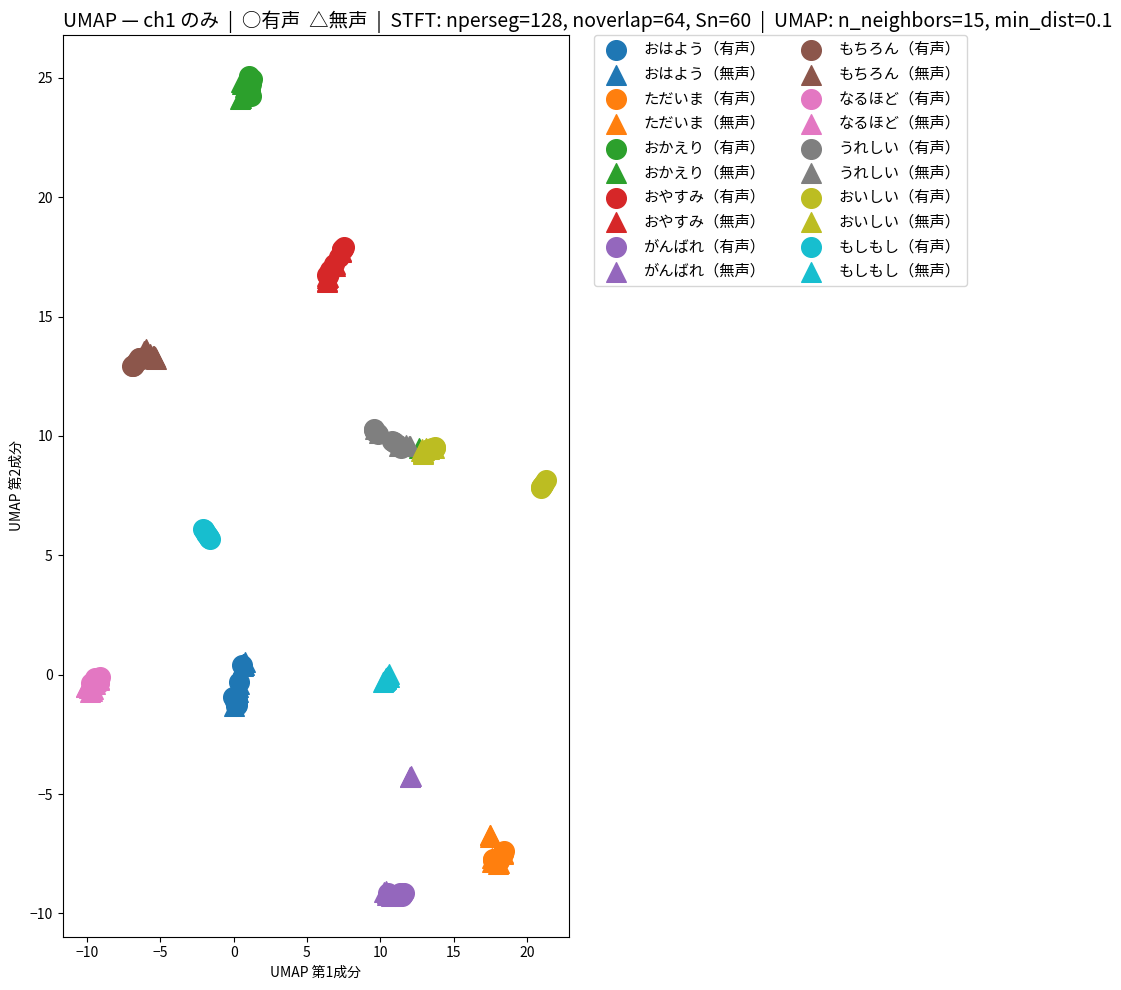

In [ ]:
plot_umap(
    embedding       = umap_ch1.embedding_,
    word_labels     = WORD_LABELS,
    colors          = COLORS,
    marker_voiced   = MARKER_VOICED,
    marker_unvoiced = MARKER_UNVOICED,
    n_samples       = N_SAMPLES,
    title           = 'UMAP — ch1 のみ  |  ○有声  △無声  |  '
                      f'STFT: nperseg={NPERSEG}, noverlap={NOVERLAP}, Sn={SN}  |  '
                      f'UMAP: n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST}'
)

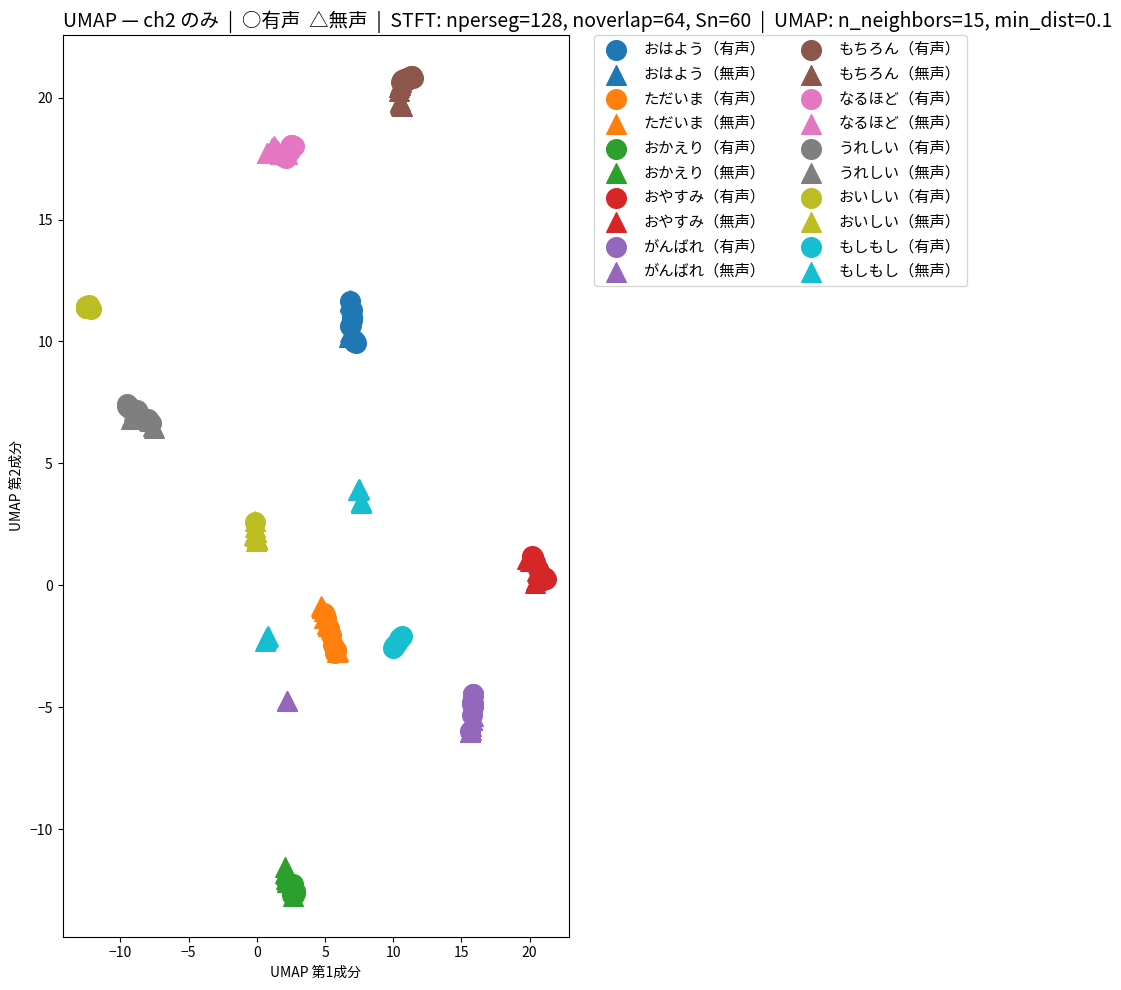

In [ ]:
plot_umap(
    embedding       = umap_ch2.embedding_,
    word_labels     = WORD_LABELS,
    colors          = COLORS,
    marker_voiced   = MARKER_VOICED,
    marker_unvoiced = MARKER_UNVOICED,
    n_samples       = N_SAMPLES,
    title           = 'UMAP — ch2 のみ  |  ○有声  △無声  |  '
                      f'STFT: nperseg={NPERSEG}, noverlap={NOVERLAP}, Sn={SN}  |  '
                      f'UMAP: n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST}'
)

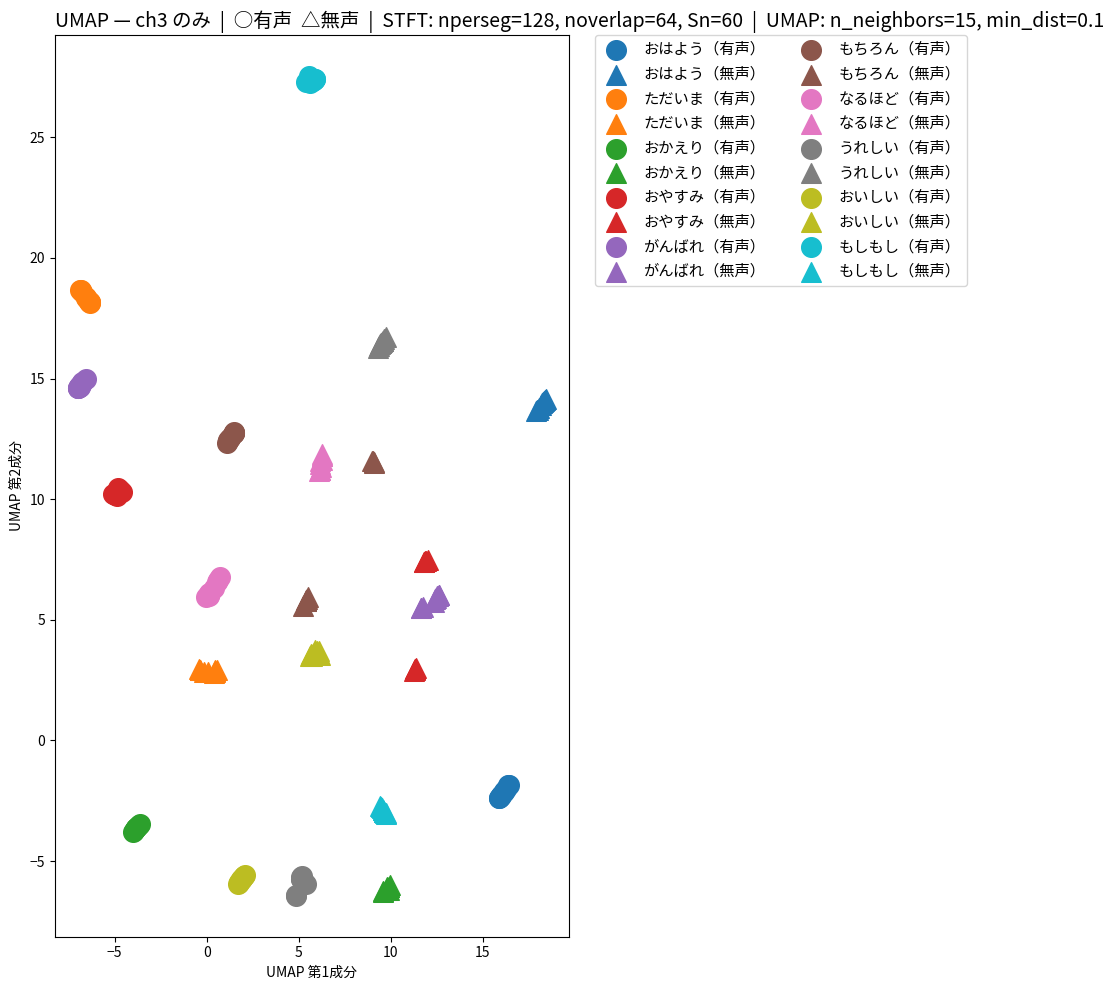

In [ ]:
plot_umap(
    embedding       = umap_ch3.embedding_,
    word_labels     = WORD_LABELS,
    colors          = COLORS,
    marker_voiced   = MARKER_VOICED,
    marker_unvoiced = MARKER_UNVOICED,
    n_samples       = N_SAMPLES,
    title           = 'UMAP — ch3 のみ  |  ○有声  △無声  |  '
                      f'STFT: nperseg={NPERSEG}, noverlap={NOVERLAP}, Sn={SN}  |  '
                      f'UMAP: n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST}'
)

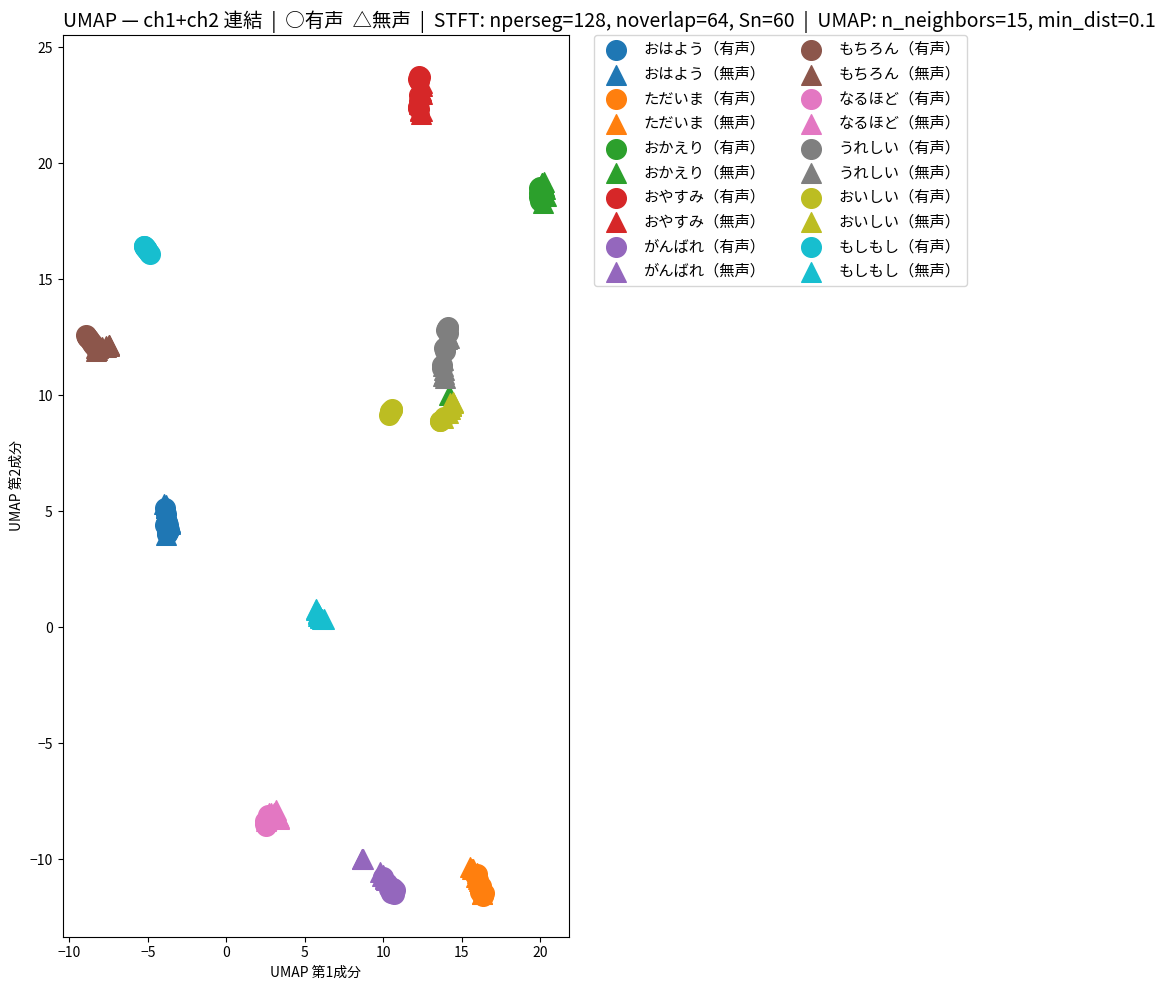

In [ ]:
plot_umap(
    embedding       = umap_ch12.embedding_,
    word_labels     = WORD_LABELS,
    colors          = COLORS,
    marker_voiced   = MARKER_VOICED,
    marker_unvoiced = MARKER_UNVOICED,
    n_samples       = N_SAMPLES,
    title           = 'UMAP — ch1+ch2 連結  |  ○有声  △無声  |  '
                      f'STFT: nperseg={NPERSEG}, noverlap={NOVERLAP}, Sn={SN}  |  '
                      f'UMAP: n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST}'
)

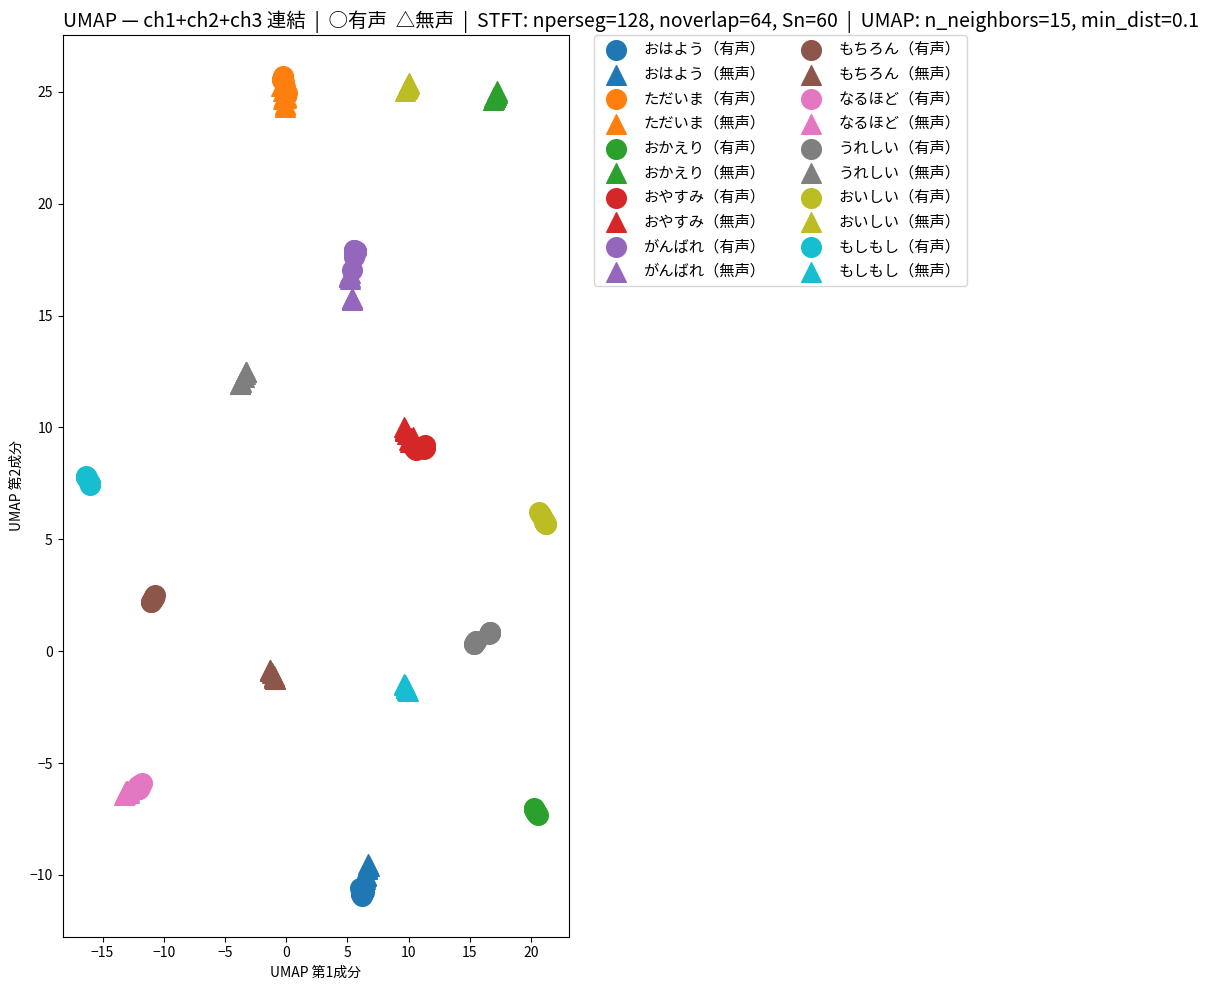

In [ ]:
plot_umap(
    embedding       = umap_ch123.embedding_,
    word_labels     = WORD_LABELS,
    colors          = COLORS,
    marker_voiced   = MARKER_VOICED,
    marker_unvoiced = MARKER_UNVOICED,
    n_samples       = N_SAMPLES,
    title           = 'UMAP — ch1+ch2+ch3 連結  |  ○有声  △無声  |  '
                      f'STFT: nperseg={NPERSEG}, noverlap={NOVERLAP}, Sn={SN}  |  '
                      f'UMAP: n_neighbors={N_NEIGHBORS}, min_dist={MIN_DIST}'
)